In [1]:
import time
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split , cross_validate , cross_val_predict
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder , MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix , recall_score , ConfusionMatrixDisplay , precision_score , f1_score, RocCurveDisplay



In [2]:
dataframe = pd.read_csv("../processed_data/procesed_customer_churn.csv")
df = dataframe.copy()

In [3]:
df = df.drop(columns=['Unnamed: 0' , 'CustomerID'])

# Model Training 


In [4]:
df.shape

(440832, 11)

In [5]:
X = df.drop(columns=["Churn"])
Y = df["Churn"]


In [6]:
X.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,30,Female,39,14,5,18,Standard,Annual,932.0,17
1,65,Female,49,1,10,8,Basic,Monthly,557.0,6
2,55,Female,14,4,6,18,Basic,Quarterly,185.0,3
3,58,Male,38,21,7,7,Standard,Monthly,396.0,29
4,23,Male,32,20,5,8,Basic,Monthly,617.0,20


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42 , stratify=Y) 
## using startify for class imbalance in target

In [8]:
preprocessor = ColumnTransformer(
    transformers= [
        ("cat_encoder" , OneHotEncoder(drop="first", sparse_output=False) , ["Gender" ,"Subscription Type" , "Contract Length"])

    ],
    remainder="passthrough"
)
## no need of scaling for Tree based algorithms as they are scale innvariant

In [9]:
dt_pipe = Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))

]
)

### Cross Validation:

In [10]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cr_val_score = cross_validate(dt_pipe , X_train , y_train , cv=5 , scoring=scoring)
print("Mean Accuracy:", cr_val_score["test_accuracy"].mean())
print("Mean Precision:", cr_val_score["test_precision"].mean())
print("Mean Recall:", cr_val_score["test_recall"].mean())




Mean Accuracy: 0.9997192803368637
Mean Precision: 0.9997650043727907
Mean Recall: 0.999739998874972


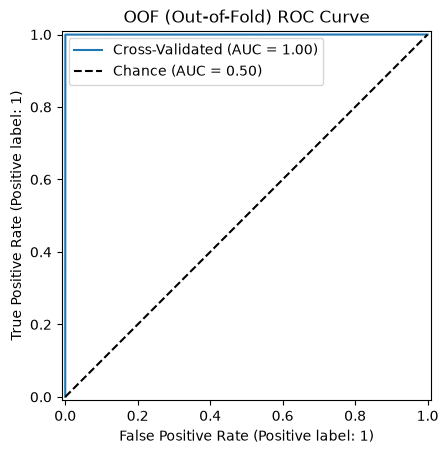

In [11]:
# 2. Generate out-of-fold probabilities for the plot
# This generates clean predictions across your folds without data leakage
y_probas = cross_val_predict(
    dt_pipe, X_train, y_train, cv=5, method="predict_proba"
)

# 3. Plot the combined ROC Curve
# y_probas[:, 1] extracts probabilities for the positive class
RocCurveDisplay.from_predictions(
    y_train, 
    y_probas[:, 1], 
    name="Cross-Validated"
)

plt.plot([0, 1], [0, 1], "k--", label="Chance (AUC = 0.50)")
plt.title("OOF (Out-of-Fold) ROC Curve")
plt.legend()
plt.show()

### Training time:

In [12]:
start_train = time.perf_counter()
dt_pipe.fit(X_train, y_train)
end_train = time.perf_counter()


training_time = end_train -  start_train
print(f"Training time: {training_time:.6f} seconds")

Training time: 1.464309 seconds


### Prediction Time:

In [13]:
start_predict = time.perf_counter()
y_pred = dt_pipe.predict(X_test)
end_predict = time.perf_counter()


prediction_time  =  end_predict - start_predict
print(f"Prediction time: {prediction_time:.6f} seconds")



Prediction time: 0.096560 seconds


### Evaluation Matrix

Testing Scores::
Classification_report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     38167
           1       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



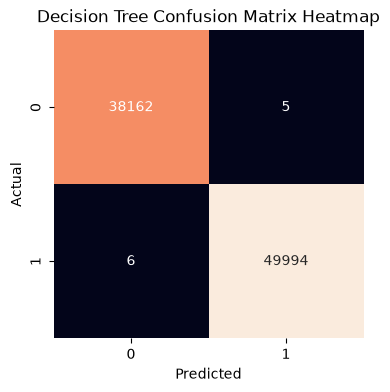

In [14]:

print("Testing Scores::")
report_test = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
print(f"Classification_report: {classification_report(y_test , y_pred)}")
cm = confusion_matrix(y_test , y_pred)
plt.figure(figsize=(4,4))
sns.heatmap(cm , annot=True ,fmt="d" , cbar=False)
plt.title("Evaluationn on Test Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix Heatmap")

plt.savefig('../benchmark_outputs/Decsision_Tree_confusion_matrix.png', bbox_inches='tight')
plt.show()

## Experiment:  Shallow vs Deep Tree

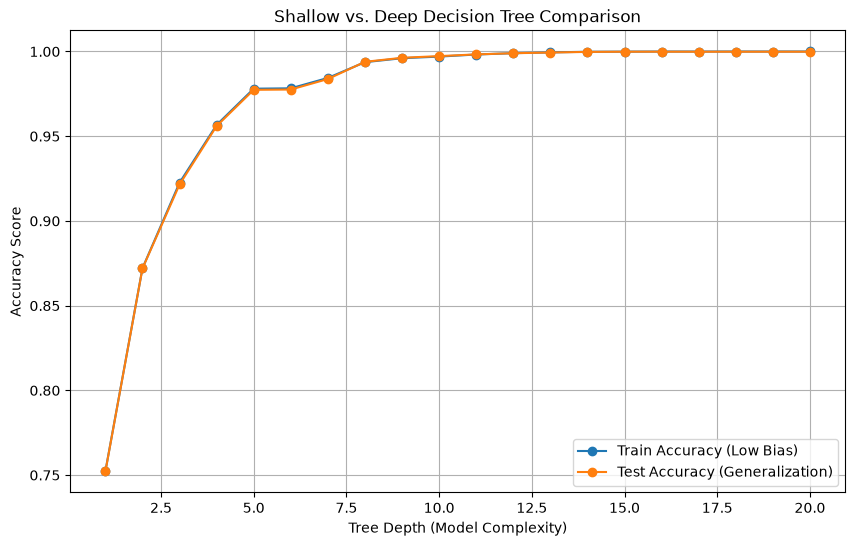

In [15]:

# 2. Track accuracies across different depths
depths = range(1, 21)
train_scores = []
test_scores = []

for depth in depths:
    # Train the tree
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("dt", DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])
  
    pipe.fit(X_train, y_train)

    # Record performance
    train_scores.append(pipe.score(X_train, y_train))
    test_scores.append(pipe.score(X_test, y_test))

# 3. Plot the performance comparison
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, label="Train Accuracy (Low Bias)", marker="o")
plt.plot(depths, test_scores, label="Test Accuracy (Generalization)", marker="o")
plt.xlabel("Tree Depth (Model Complexity)")
plt.ylabel("Accuracy Score")
plt.title("Shallow vs. Deep Decision Tree Comparison")

plt.savefig('../benchmark_outputs/Shallow_vs_DeepTree.png', bbox_inches='tight')
plt.legend()
plt.grid(True)
plt.show()


### Saving the model for final preddictions

In [16]:
import joblib

# 1. Save your trained pipeline to a file
joblib.dump(dt_pipe, '../models/Decision_tree_model_pipeline.joblib')


['../models/Decision_tree_model_pipeline.joblib']